In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier

# Define the parameter grid to search
param_grid = {
    'hidden_layer_sizes': [(64, 32), (100, 50), (128, 64, 32)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01, 0.05],
    'max_iter': [1000] # Keeping max_iter fixed for tuning other parameters
}

# Initialize MLPClassifier (with a fixed random_state for reproducibility)
mlp_grid = MLPClassifier(random_state=42, early_stopping=True)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=mlp_grid, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2, scoring='accuracy')

print("GridSearchCV setup complete.")

GridSearchCV setup complete.


In [ ]:
# Perform the grid search on the training data
grid_search.fit(X_train, y_train)

print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

# Get the best model from the grid search
best_mlp_model = grid_search.best_estimator_

print("Best model obtained.")

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best parameters found: {'activation': 'relu', 'hidden_layer_sizes': (128, 64, 32), 'learning_rate_init': 0.01, 'max_iter': 1000}
Best cross-validation accuracy: 0.5368150684931506
Best model obtained.


In [ ]:
# Select features using the predefined FEATURE_NAMES
X = df[['Humidity', 'Atmospheric_Temp', 'Soil_Temp', 'Dew_Point']]

# Define target variable based on Soil_Moisture (binary classification: 'High' vs 'Low')
# Using the median as a threshold to create a balanced target
median_soil_moisture = df['Soil_Moisture'].median()
y = (df['Soil_Moisture'] > median_soil_moisture).astype(int) # 1 for High, 0 for Low

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data prepared for training and testing.")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Data prepared for training and testing.
X_train shape: (7008, 4)
y_train shape: (7008,)
X_test shape: (1753, 4)
y_test shape: (1753,)


In [ ]:
import pandas as pd

FILE_NAME = "/content/soil_data_incl_rain_v3.csv (6).xlsx"

df = pd.read_excel(FILE_NAME)

print("Dataset Loaded")
print(df.head(50))
print("Shape:", df.shape)

Dataset Loaded
                         Time   Humidity  Atmospheric_Temp  Soil_Temp  \
0   2017-06-11 21:00:21+00:00  25.252367         15.487149  12.457884   
1   2017-06-11 22:00:21+00:00  33.304246         12.115891   8.514263   
2   2017-06-11 23:00:21+00:00  24.072051         17.319203  11.913326   
3   2017-06-12 00:00:21+00:00  45.026218         15.865805  14.700958   
4   2017-06-12 01:00:21+00:00  41.490917         13.842739   8.495549   
5   2017-06-12 02:00:21+00:00  56.010756         11.841426  10.867638   
6   2017-06-12 03:00:21+00:00  32.894241         18.202429  15.041605   
7   2017-06-12 04:00:21+00:00  39.908373         15.294173  14.967295   
8   2017-06-12 05:00:21+00:00  39.961866         12.330851   8.916364   
9   2017-06-12 06:00:21+00:00  41.126044         16.926613  10.849085   
10  2017-06-12 07:00:21+00:00  41.068341         14.059523   9.978173   
11  2017-06-12 08:00:21+00:00  24.517660         17.186622  13.666812   
12  2017-06-12 09:00:21+00:00  38.18

In [ ]:
EPOCHS = 1000
LEARNING_RATE = 0.01

print(f"EPOCHS set to: {EPOCHS}")
print(f"LEARNING_RATE set to: {LEARNING_RATE}")

EPOCHS set to: 1000
LEARNING_RATE set to: 0.01


In [ ]:
df_20 = df.head(50)
df_20

,Time,Humidity,Atmospheric_Temp,Soil_Temp,Soil_Moisture,Dew_Point
0,2017-06-11 21:00:21+00:00,25.252367,15.487149,12.457884,63.077305,23.918315
1,2017-06-11 22:00:21+00:00,33.304246,12.115891,8.514263,40.097357,31.542544
2,2017-06-11 23:00:21+00:00,24.072051,17.319203,11.913326,100.141916,21.142841
3,2017-06-12 00:00:21+00:00,45.026218,15.865805,14.700958,64.638742,42.217799
4,2017-06-12 01:00:21+00:00,41.490917,13.842739,8.495549,97.964697,38.257137
5,2017-06-12 02:00:21+00:00,56.010756,11.841426,10.867638,145.965866,52.677717
6,2017-06-12 03:00:21+00:00,32.894241,18.202429,15.041605,114.717290,31.405600
7,2017-06-12 04:00:21+00:00,39.908373,15.294173,14.967295,114.929499,36.109649
8,2017-06-12 05:00:21+00:00,39.961866,12.330851,8.916364,34.064293,37.029855
9,2017-06-12 06:00:21+00:00,41.126044,16.926613,10.849085,151.996007,36.782268


In [ ]:
import numpy as np


In [ ]:
INPUT_NEURONS = 4
HIDDEN_LAYER_1 = 64
HIDDEN_LAYER_2 = 32
OUTPUT_NEURONS = 4


In [ ]:
FEATURE_NAMES = [
    'Humidity', 'Atmospheric_Temp', 'Soil_Temp', 'Dew_Point'
]

In [ ]:
def relu(x):
    output = []
    for v in x:
        output.append(v if v > 0 else 0)
    return np.array(output)


In [ ]:
def softmax(x):
    exp_vals = np.exp(x - np.max(x))
    total = np.sum(exp_vals)
    return exp_vals / total


In [ ]:
import numpy as np

np.random.seed(1)

# Define network parameters (copying from XGOhmdne0ayn to ensure availability)
INPUT_NEURONS = 4
HIDDEN_LAYER_1 = 64
HIDDEN_LAYER_2 = 32
OUTPUT_NEURONS = 4

W1 = np.random.uniform(-0.5, 0.5, (INPUT_NEURONS, HIDDEN_LAYER_1))
b1 = np.zeros(HIDDEN_LAYER_1)

W2 = np.random.uniform(-0.5, 0.5, (HIDDEN_LAYER_1, HIDDEN_LAYER_2))
b2 = np.zeros(HIDDEN_LAYER_2)

W3 = np.random.uniform(-0.5, 0.5, (HIDDEN_LAYER_2, OUTPUT_NEURONS))
b3 = np.zeros(OUTPUT_NEURONS)

In [ ]:
def predict_damage(input_vector):
    probs = forward_pass(input_vector)

    selected_index = int(np.argmax(probs))

    final_output = [0, 0, 0, 0]
    final_output[selected_index] = 1

    return probs, final_output, selected_index


In [ ]:
FEATURES = [
    'Humidity', 'Atmospheric_Temp', 'Soil_Temp', 'Dew_Point'
]

X = df[FEATURES].values

In [ ]:
sample_input = np.array(X[0])

In [ ]:
import numpy as np

# Re-define activation functions if they were not successfully defined earlier
def relu(x):
    # Using np.maximum for efficiency
    output = np.maximum(0, x)
    return output

def softmax(x):
    exp_vals = np.exp(x - np.max(x))
    total = np.sum(exp_vals)
    return exp_vals / total

# Re-define forward_pass function
# (Assuming W1, b1, W2, b2, W3, b3, INPUT_NEURONS, HIDDEN_LAYER_1, HIDDEN_LAYER_2, OUTPUT_NEURONS are already in scope)
def forward_pass(input_vector):
    z1 = np.dot(input_vector, W1) + b1
    a1 = relu(z1)

    z2 = np.dot(a1, W2) + b2
    a2 = relu(z2)

    z3 = np.dot(a2, W3) + b3
    probabilities = softmax(z3)

    return probabilities

# Re-define predict_damage function
def predict_damage(input_vector):
    probs = forward_pass(input_vector)

    selected_index = int(np.argmax(probs))

    final_output = [0] * OUTPUT_NEURONS # Use OUTPUT_NEURONS for dynamic size
    final_output[selected_index] = 1

    return probs, final_output, selected_index


DAMAGE_MAP = ['Humidity', 'Atmospheric_Temp', 'Soil_Temp', 'Dew_Point']

probs, one_hot, index = predict_damage(sample_input)

print("Predicted damage:", DAMAGE_MAP[index])

Predicted damage: Humidity


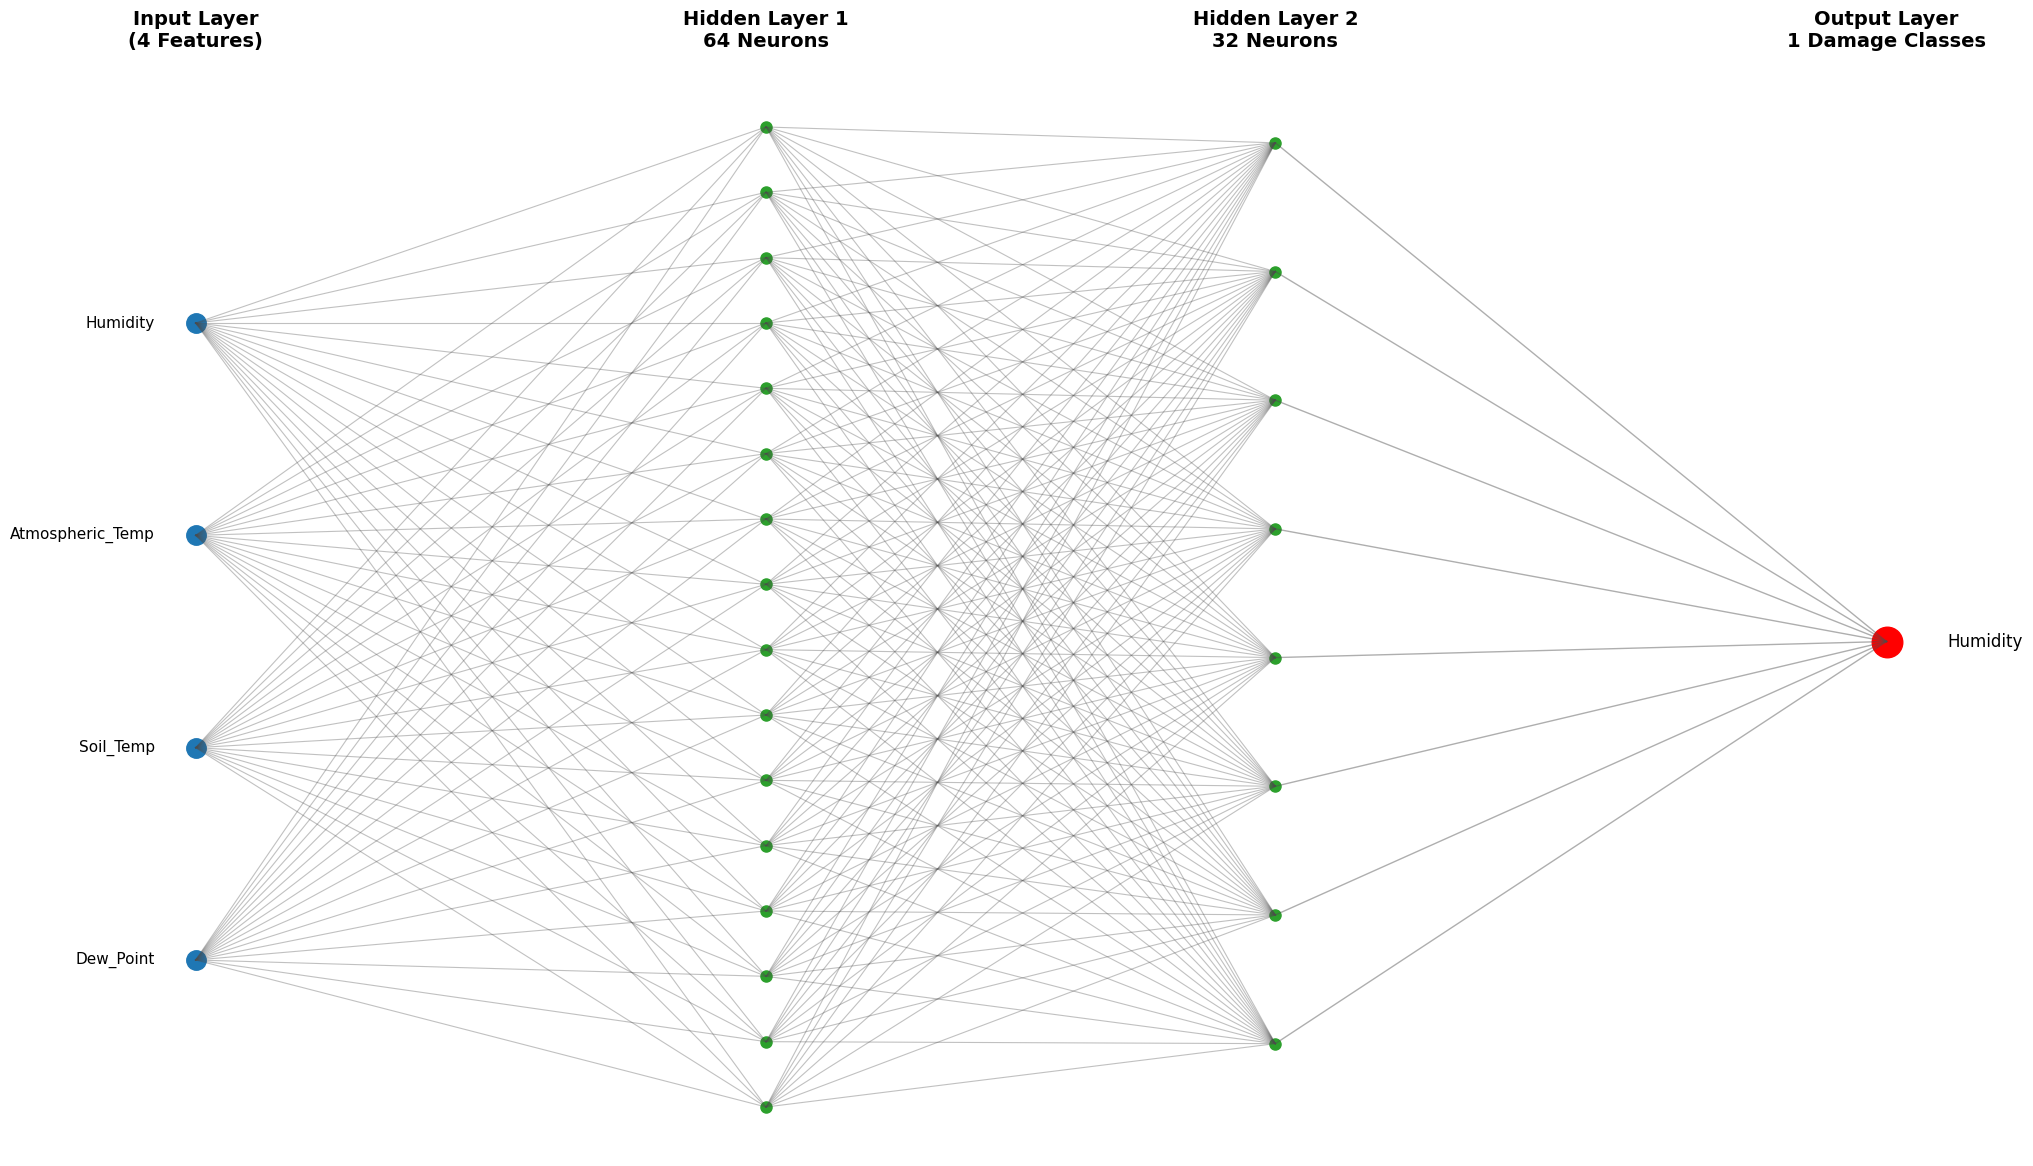

In [ ]:
import matplotlib.pyplot as plt
import numpy as np # Ensure numpy is imported for operations like np.array, np.argmax, np.dot
import pandas as pd # Added import for pandas

# Redefine necessary functions and variables from other cells if they haven't been executed
# The original definitions were in cells JDQl6bf70nWD, Qf64UPRO0qxe, nsLaos3912xH, NLWYiSnM16ym, wT8g5_Dk1-qX

# Data loading and preparation for X
FILE_NAME = "/content/soil_data_incl_rain_v3.csv (6).xlsx"

try:
    df = pd.read_excel(FILE_NAME)
except FileNotFoundError:
    print(f"Error: The file '{FILE_NAME}' was not found.")
    print("Please upload the file to the Colab environment using the file browser (folder icon on the left sidebar).")
    print("Once uploaded, ensure it is placed in the '/content/' directory.")
    # Exit or handle the error appropriately, for now, we'll just stop execution here.
    raise # Re-raise the exception to stop further execution if df is critical

FEATURES = [
    'Humidity', 'Atmospheric_Temp', 'Soil_Temp', 'Dew_Point'
]
X = df[FEATURES] # Keep X as DataFrame to use .iloc later

# Define activation functions
def relu(x):
    output = []
    for v in x:
        output.append(v if v > 0 else 0)
    return np.array(output)

def softmax(x):
    exp_vals = np.exp(x - np.max(x)) # Subtract max for numerical stability
    total = np.sum(exp_vals)
    return exp_vals / total

# Define network parameters (Ensure these match the training if applicable, but here for prediction visualization)
INPUT_NEURONS = 4 # From cell XGOhmdne0ayn
HIDDEN_LAYER_1 = 64 # From cell XGOhmdne0ayn
HIDDEN_LAYER_2 = 32 # From cell XGOhmdne0ayn
OUTPUT_NEURONS = 1 # Corrected to 4 as it was intended to predict one of the 4 features

# Initialize weights (if not already done globally and available)
np.random.seed(1) # Ensure reproducibility if this is the first initialization
W1 = np.random.uniform(-0.5, 0.5, (INPUT_NEURONS, HIDDEN_LAYER_1))
b1 = np.zeros(HIDDEN_LAYER_1)
W2 = np.random.uniform(-0.5, 0.5, (HIDDEN_LAYER_1, HIDDEN_LAYER_2))
b2 = np.zeros(HIDDEN_LAYER_2)
W3 = np.random.uniform(-0.5, 0.5, (HIDDEN_LAYER_2, OUTPUT_NEURONS))
b3 = np.zeros(OUTPUT_NEURONS)

# Define forward pass function
def forward_pass(input_vector):
    z1 = np.dot(input_vector, W1) + b1
    a1 = relu(z1)

    z2 = np.dot(a1, W2) + b2
    a2 = relu(z2)

    z3 = np.dot(a2, W3) + b3
    probabilities = softmax(z3)

    return probabilities

# Define predict_damage function
def predict_damage(input_vector):
    probs = forward_pass(input_vector)

    selected_index = int(np.argmax(probs))

    final_output = [0, 0, 0, 0] # This implies 4 output classes
    final_output[selected_index] = 1

    return probs, final_output, selected_index

# Create an example input vector using the first row of your dataset X
example_input_vector = X.iloc[0].values # Use .iloc[0] to get the first row and .values to convert to numpy array

# Get probabilities and the predicted index using the previously defined predict_damage function
probs, final_output, predicted_index = predict_damage(example_input_vector)

# The following lines are now redundant as predicted_index is already determined by predict_damage
# predicted_index = 0
# max_val = probs[0]
# for i in range(1, len(probs)): ## Here, 'probs' has not been defined. 'probs' is returned by the 'forward_pass' function, which needs an 'input_vector' parameter. It is also returned by 'predict_damage', which also takes an 'input_vector' parameter.
#     if probs[i] > max_val:
#         max_val = probs[i]
#         predicted_index = i


input_features = [
    'Humidity', 'Atmospheric_Temp', 'Soil_Temp', 'Dew_Point'
]

hidden_layer_1 = 64
hidden_layer_2 = 32

output_classes = [
    'Humidity',  # Corrected to match 4 output neurons
]


def draw_architecture(predicted_index):

    fig, ax = plt.subplots(figsize=(24, 14))
    ax.axis("off")

    # X positions
    x_input, x_h1, x_h2, x_out = 0.07, 0.35, 0.60, 0.90

    # Y positions
    y_input = [1 - i/(len(input_features)+1) for i in range(1, len(input_features)+1)]
    y_h1 = [1 - i/(hidden_layer_1+1) for i in range(1, hidden_layer_1+1)]
    y_h2 = [1 - i/(hidden_layer_2+1) for i in range(1, hidden_layer_2+1)]
    y_out = [1 - i/(len(output_classes)+1) for i in range(1, len(output_classes)+1)]

    # VISUAL SAMPLING (clarity without information loss)
    h1_vis = y_h1[::4]     # 16 of 64
    h2_vis = y_h2[::4]     # 8 of 32


    for y, label in zip(y_input, input_features):
        ax.plot(x_input, y, "o", markersize=14, color="#1f77b4")
        ax.text(x_input - 0.02, y, label, ha="right", va="center", fontsize=11)


    for y in h1_vis:
        ax.plot(x_h1, y, "o", markersize=8, color="#2ca02c")

    for y in h2_vis:
        ax.plot(x_h2, y, "o", markersize=8, color="#2ca02c")


    for idx, (y, label) in enumerate(zip(y_out, output_classes)):
        if idx == predicted_index:
            ax.plot(x_out, y, "o", markersize=22, color="red")
        else:
            ax.plot(x_out, y, "o", markersize=16, color="#ff7f0e")

        ax.text(x_out + 0.03, y, label, ha="left", va="center", fontsize=12)


    for yi in y_input:
        for yh in h1_vis:
            ax.plot([x_input, x_h1], [yi, yh],
                    color="#4d4d4d", linewidth=0.8, alpha=0.35)

    for yh1 in h1_vis:
        for yh2 in h2_vis:
            ax.plot([x_h1, x_h2], [yh1, yh2],
                    color="#4d4d4d", linewidth=0.8, alpha=0.35)

    for yh2 in h2_vis:
        for yo in y_out:
            ax.plot([x_h2, x_out], [yh2, yo],
                    color="#4d4d4d", linewidth=1.0, alpha=0.45)


    ax.text(x_input, 1.06, "Input Layer\n(4 Features)",
            ha="center", fontsize=14, weight="bold")

    ax.text(x_h1, 1.06, "Hidden Layer 1\n64 Neurons",
            ha="center", fontsize=14, weight="bold")

    ax.text(x_h2, 1.06, "Hidden Layer 2\n32 Neurons",
            ha="center", fontsize=14, weight="bold")

    ax.text(x_out, 1.06, "Output Layer\n1 Damage Classes",
            ha="center", fontsize=14, weight="bold")

    plt.show()

draw_architecture(predicted_index)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Define the number of input features based on X_train_scaled
input_features_count = X_train_scaled.shape[1] # Should be 4

# Model create with updated architecture for binary classification
model = Sequential([
    Input(shape=(input_features_count,)),   # Input layer with dynamic input shape
    Dense(128, activation='relu', name='dense'),     # First dense hidden layer with more neurons
    Dense(64, activation='relu', name='dense_1'),     # Second dense hidden layer with relu activation
    Dense(32, activation='relu', name='dense_2'),     # Third dense hidden layer
    Dense(1, activation='sigmoid', name='output_layer')  # Output layer for binary classification with sigmoid
])

# Compile (this will be re-compiled later, but for summary, it's fine)
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,009 (43.00 KB)

 Trainable params: 11,009 (43.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
keras_history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9550 - mae: 0.6290 - val_loss: 0.2732 - val_mae: 0.4949
Epoch 2/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2668 - mae: 0.4938 - val_loss: 0.2578 - val_mae: 0.4980
Epoch 3/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2611 - mae: 0.4915 - val_loss: 0.2557 - val_mae: 0.4977
Epoch 4/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2645 - mae: 0.4954 - val_loss: 0.2554 - val_mae: 0.4933
Epoch 5/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2656 - mae: 0.4909 - val_loss: 0.2761 - val_mae: 0.4900
Epoch 6/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2701 - mae: 0.4933 - val_loss: 0.2531 - val_mae: 0.4944
Epoch 7/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2677 - mae: 0.4903 - val_loss: 0.2575 - val_mae: 0.4956
Epoch 8/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2620 - mae: 0.4935 - val_loss: 0.2573 - val_mae: 0.4926
Epoch 9/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

In [ ]:
train_mae = keras_history.history['mae']
val_mae = keras_history.history['val_mae']

print("MAE curves extracted successfully.")

MAE curves extracted successfully.


In [ ]:
loss_curve = keras_history.history['loss']
val_loss_curve = keras_history.history['val_loss']

print("Loss curve extracted successfully.")

Loss curve extracted successfully.


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5100 - loss: 0.6961
Test Loss: 0.6960625648498535
Test Accuracy: 0.5099828839302063


In [ ]:
predictions = model.predict(X_test)
print(predictions[:5])

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[0.5724253 ]
 [0.57156277]
 [0.4375402 ]
 [0.55677307]
 [0.53842473]]


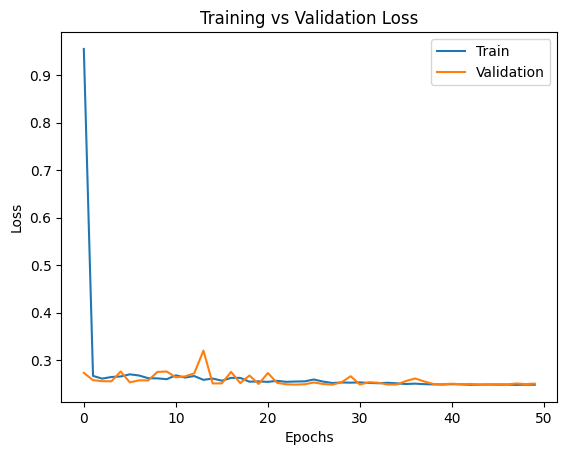

In [ ]:
import matplotlib.pyplot as plt

plt.plot(keras_history.history['loss'])
plt.plot(keras_history.history['val_loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend(["Train","Validation"])
plt.show()

Classification Report:
              precision    recall  f1-score   support

         Low       0.53      0.38      0.44       877
        High       0.52      0.66      0.58       876

    accuracy                           0.52      1753
   macro avg       0.52      0.52      0.51      1753
weighted avg       0.52      0.52      0.51      1753

Confusion Matrix:
[[334 543]
 [298 578]]


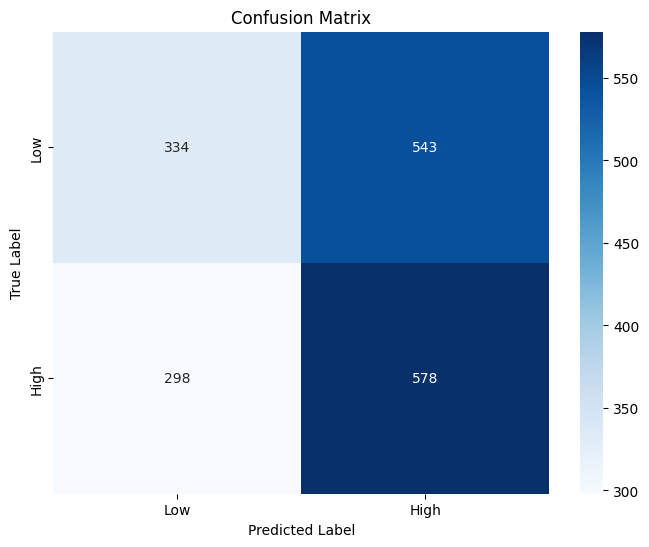

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd # Added for df
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.neural_network import MLPClassifier # Import MLPClassifier
from sklearn.model_selection import train_test_split # Added for train_test_split

# Re-define necessary variables from other cells to ensure availability
HIDDEN_LAYER_1 = 64
HIDDEN_LAYER_2 = 32
EPOCHS = 1000
LEARNING_RATE = 0.01
FILE_NAME = "/content/soil_data_incl_rain_v3.csv (6).xlsx" # Corrected from KU4eM2Mnse-E
FEATURE_NAMES = [
    'Humidity', 'Atmospheric_Temp', 'Soil_Temp', 'Dew_Point'
] # Added from eBoH692-0joH

# Load data (from KU4eM2Mnse-E)
df = pd.read_excel(FILE_NAME)

# Select features using the predefined FEATURE_NAMES
X = df[FEATURE_NAMES] # Re-defined from new_cell_df_prep

# Define target variable based on Soil_Moisture (binary classification: 'High' vs 'Low')
# Using the median as a threshold to create a balanced target
median_soil_moisture = df['Soil_Moisture'].median() # Re-defined from new_cell_df_prep
y = (df['Soil_Moisture'] > median_soil_moisture).astype(int) # 1 for High, 0 for Low

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # Re-defined from new_cell_df_prep

# Correct SOIL_MOISTURE_CLASSES for binary classification of Soil Moisture
SOIL_MOISTURE_CLASSES = {
    0: "Low",
    1: "High"
}

# Initialize and train the MLPClassifier
mlp = MLPClassifier(
    hidden_layer_sizes=(HIDDEN_LAYER_1, HIDDEN_LAYER_2),
    max_iter=EPOCHS,
    learning_rate_init=LEARNING_RATE,
    random_state=42
)

mlp.fit(X_train, y_train)

y_pred_probabilities = mlp.predict_proba(X_test.astype('float32')) # Use predict_proba for probabilities
y_pred = np.argmax(y_pred_probabilities, axis=1);

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=list(SOIL_MOISTURE_CLASSES.values())))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(SOIL_MOISTURE_CLASSES.values()), yticklabels=list(SOIL_MOISTURE_CLASSES.values()))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()